## C-V Characteristic Modeling

1. import

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from phis_init import *
from Residual import *
from CVModeling import (
    G_phigd,
    Cjfet,
    Cgd,
    Cds,
    Cds_no_PT,
    Cgs,
)

2. Parameters

In [2]:
# ============================================================
# Device / numerical settings
# ============================================================

device = "cpu"
dtype = torch.float32


# ============================================================
# Surface-potential parameters
# ============================================================

T = 300.0                         # K

NA = 1.0e16                      # cm^-3

ND = 5.0e16                      # cm^-3


# ============================================================
# 4H-SiC parameters
# ============================================================

Eg = 3.26                        # eV

eps_sic = (
    9.26
    * 8.854e-14
)                                # F/cm


# ============================================================
# Gate oxide
# ============================================================

Cox = 7.0e-8                     # F/cm^2


# ============================================================
# Flat-band voltage
# ============================================================

Vfbs0 = -1.0                     # V


# ============================================================
# Interface traps
# ============================================================

Dit_mid = 2.0e11                 # cm^-2 eV^-1

Dit_edge = 2.0e13                # cm^-2 eV^-1

sigma_it = 0.1                   # eV


# ============================================================
# Device geometry
# ============================================================

Agd = 3.15e-2                    # cm^2

Ads = 2.97e-2                    # cm^2

# ============================================================
# C-V parameters
# ============================================================

def calc_Vbi(
    ref,
    NA,
    ND,
    T,
    Eg,
):
    

    # --------------------------------------------------------
    # Use float64 internally for numerical stability
    # --------------------------------------------------------

    device_local = ref.device

    calc_dtype = torch.float64


    # --------------------------------------------------------
    # Physical constants
    # --------------------------------------------------------

    q_local = torch.as_tensor(
        1.602e-19,
        dtype=calc_dtype,
        device=device_local,
    )

    k_B_local = torch.as_tensor(
        1.381e-23,
        dtype=calc_dtype,
        device=device_local,
    )


    # --------------------------------------------------------
    # Device parameters
    # --------------------------------------------------------

    T_local = torch.as_tensor(
        T,
        dtype=calc_dtype,
        device=device_local,
    )

    NA_local = torch.as_tensor(
        NA,
        dtype=calc_dtype,
        device=device_local,
    )

    ND_local = torch.as_tensor(
        ND,
        dtype=calc_dtype,
        device=device_local,
    )


    # --------------------------------------------------------
    # Reference tensor for ni calculation
    #
    # ni_4H_SiC uses ref mainly to inherit
    # dtype and device.
    # --------------------------------------------------------

    ref_local = torch.zeros(
        1,
        dtype=calc_dtype,
        device=device_local,
    )


    # --------------------------------------------------------
    # Intrinsic carrier concentration
    # --------------------------------------------------------

    ni_local = ni_4H_SiC(
        T_local,
        Eg,
        ref=ref_local,
    )


    # --------------------------------------------------------
    # Thermal voltage
    #
    # Vt = k_B T / q
    # --------------------------------------------------------

    Vt = (
        k_B_local
        * T_local
        / q_local
    )


    # --------------------------------------------------------
    # Numerically stable logarithmic term
    #
    # Do NOT directly calculate:
    #
    # NA * ND / ni**2
    #
    # because this may overflow in float32.
    # --------------------------------------------------------

    log_term = (
        torch.log(NA_local)
        + torch.log(ND_local)
        - 2.0 * torch.log(ni_local)
    )


    # --------------------------------------------------------
    # Built-in potential
    # --------------------------------------------------------

    Vbi_local = (
        Vt
        * log_term
    )


    # --------------------------------------------------------
    # Return same dtype/device as the main simulation
    # --------------------------------------------------------

    Vbi_local = Vbi_local.to(
        dtype=ref.dtype,
        device=ref.device,
    )


    return Vbi_local


# ============================================================
# Punch-through voltage
# ============================================================

Vpt = 500.0                      # V




# ============================================================
# Gate-drain oxide capacitance
# ============================================================

Coxgd = (
    Agd
    * Cox
)

print(
    "Coxgd =",
    Coxgd * 1e12,
    "pF"
)


# ============================================================
# Cgs
# ============================================================

Cgs_const = 1200e-12             # F

Coxgd = 2205.0 pF


Add: PINN Network Duplication

In [3]:
class DeltaPhisPINN(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.Tanh(),
            nn.Linear(8, 1)
        )

        nn.init.zeros_(
            self.net[2].weight
        )

        nn.init.zeros_(
            self.net[2].bias
        )


    def forward(
        self,
        Vgs,
        Vds
    ):

        Vgs = Vgs.reshape(-1, 1)
        Vds = Vds.reshape(-1, 1)

        x = torch.cat(
            [
                Vgs,
                Vds
            ],
            dim=1
        )

        return self.net(x)

Add: Load training results

In [4]:
Model = DeltaPhisPINN().to(
    device=device,
    dtype=dtype
)

state_dict = torch.load(
    "phis_PINN.pth",
    map_location=device
)

Model.load_state_dict(
    state_dict,
    strict=True
)

Model.eval()

print(
    "Surface-potential PINN loaded."
)

Surface-potential PINN loaded.


3. C-V Voltage Sweep definition

In [5]:
# ============================================================
# C-V voltage sweep
# ============================================================

N_CV = 1001

Vds_cv = torch.linspace(
    0.0,
    1000.0,
    N_CV,
    dtype=dtype,
    device=device
).reshape(-1, 1)


# Measurement condition
VGS_CV = 0.0

Vgs_cv = torch.full_like(
    Vds_cv,
    VGS_CV
)

4. PT clamp for Cgd

In [6]:
# ============================================================
# Gate-drain voltage
#
# Vgd = Vgs - Vds
# ============================================================

Vgd_cv = (
    Vgs_cv
    - Vds_cv
)


# ============================================================
# Punch-through effective voltage
#
# For the current approximate PT treatment:
#
# |Vgd| <= Vpt
# Vds   <= Vpt
# ============================================================

Vds_eff = torch.clamp(
    Vds_cv,
    min=0.0,
    max=Vpt
)


Vgd_eff = torch.clamp(
    Vgd_cv,
    min=-Vpt,
    max=0.0
)


print(
    "Vgd range:",
    Vgd_eff.min().item(),
    "to",
    Vgd_eff.max().item(),
    "V"
)

print(
    "Vds_eff range:",
    Vds_eff.min().item(),
    "to",
    Vds_eff.max().item(),
    "V"
)

Vgd range: -500.0 to 0.0 V
Vds_eff range: 0.0 to 500.0 V


In [7]:
# ============================================================
# PINN surface-potential diagnostic ONLY
#
# WARNING:
#
# This trained PINN was NOT trained over the
# full C-V high-voltage domain.
#
# Therefore phi_gd_PINN is currently used only
# for diagnosis, NOT yet accepted as the final Cgd solution.
# ============================================================


@torch.no_grad()
def predict_phis(
    model,
    V_control,
    phi_f
):

    model.eval()

    V_control = torch.as_tensor(
        V_control,
        dtype=dtype,
        device=device
    ).reshape(-1, 1)

    phi_f = torch.as_tensor(
        phi_f,
        dtype=dtype,
        device=device
    ).reshape(-1, 1)


    phis_init_value = phi_init(
        V_control,
        phi_f,
        T,
        NA,
        eps_sic,
        Cox,
        Vfbs0,
        Dit_mid,
        Dit_edge,
        sigma_it,
        Eg,
    ).reshape(-1, 1)


    delta_phi = model(
        V_control,
        phi_f
    )


    phi_s = (
        phis_init_value
        + delta_phi
    )

    return phi_s


phi_gd_PINN = predict_phis(
    Model,
    Vgd_eff,
    Vds_eff
)


print(
    "phi_gd_PINN range =",
    phi_gd_PINN.min().item(),
    "to",
    phi_gd_PINN.max().item(),
    "V"
)

phi_gd_PINN range = -0.20746755599975586 to 0.780669093132019 V


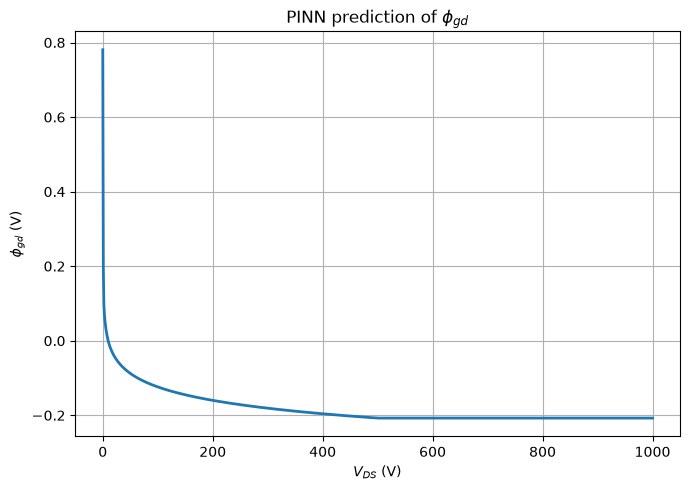

In [8]:
plt.figure(
    figsize=(7, 5)
)

plt.plot(
    Vds_cv.cpu().numpy(),
    phi_gd_PINN.cpu().numpy(),
    linewidth=2
)

plt.xlabel(
    r"$V_{DS}$ (V)"
)

plt.ylabel(
    r"$\phi_{gd}$ (V)"
)

plt.title(
    r"PINN prediction of $\phi_{gd}$"
)

plt.grid(True)

plt.tight_layout()

plt.show()

Calculate G(ϕgd) and CJFET, Cgd, Cds

In [9]:
# ============================================================
# Cds and Cgs
#
# These two do NOT depend on the questionable high-voltage
# phi_gd PINN extrapolation.
# ============================================================

with torch.no_grad():

    # --------------------------------------------------------
    # Built-in potential of PN junction
    # --------------------------------------------------------

    Vbi_value = calc_Vbi(
        ref=Vds_cv,
        NA=NA,
        ND=ND,
        T=T,
        Eg=Eg,
    )


    # --------------------------------------------------------
    # Output capacitance with punch-through treatment
    # --------------------------------------------------------

    Cds_value = Cds(
        Vds_cv,
        ND,
        eps_sic,
        Ads,
        Vbi_value,
        Vpt,
    )


    # --------------------------------------------------------
    # Output capacitance without punch-through treatment
    # --------------------------------------------------------

    Cds_no_PT_value = Cds_no_PT(
        Vds_cv,
        ND,
        eps_sic,
        Ads,
        Vbi_value,
    )


    # --------------------------------------------------------
    # Gate-source capacitance
    # --------------------------------------------------------

    Cgs_value = Cgs(
        Vds_cv,
        Cgs_const,
    )


# ============================================================
# Diagnostic
# ============================================================

print(
    "Vbi =",
    Vbi_value.item(),
    "V"
)

Vbi = 2.909670352935791 V


c:\Users\zipeng\Desktop\NNProject\Neural-Network_Internship_2026\.github\src\CVModeling.py:360: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than tensor.new_tensor(sourceTensor).
  Vbi_t = Vds.new_tensor(


F to pF

In [10]:
Cds_pF = (
    Cds_value
    * 1e12
)

Cds_no_PT_pF = (
    Cds_no_PT_value
    * 1e12
)

Cgs_pF = (
    Cgs_value
    * 1e12
)

Print representative values

In [11]:
# ============================================================
# Cds sanity check
# ============================================================

test_voltages = [
    0.0,
    1.0,
    10.0,
    50.0,
    100.0,
    200.0,
    500.0,
    800.0,
    1000.0,
]


print(
    "Vds(V)    "
    "Cds(pF)    "
    "Cds_no_PT(pF)    "
    "Cgs(pF)"
)

print("-" * 60)


for V in test_voltages:

    idx = torch.argmin(
        torch.abs(
            Vds_cv.flatten()
            - V
        )
    )

    print(
        f"{V:7.1f}    "
        f"{Cds_pF[idx].item():10.3f}    "
        f"{Cds_no_PT_pF[idx].item():10.3f}    "
        f"{Cgs_pF[idx].item():10.3f}"
    )

Vds(V)    Cds(pF)    Cds_no_PT(pF)    Cgs(pF)
------------------------------------------------------------
    0.0       997.781       997.781      1200.000
    1.0       860.769       860.769      1200.000
   10.0       473.696       473.696      1200.000
   50.0       233.986       233.986      1200.000
  100.0       167.776       167.776      1200.000
  200.0       119.483       119.483      1200.000
  500.0        75.895        75.895      1200.000
  800.0        75.895        60.065      1200.000
 1000.0        75.895        53.744      1200.000


10. Plot

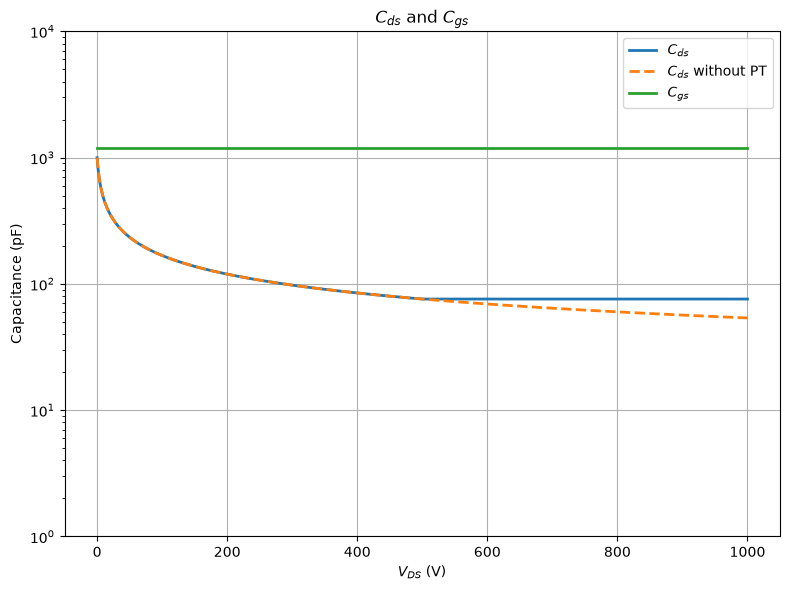

In [12]:
# ============================================================
# Cds / Cgs validation
# ============================================================

plt.figure(
    figsize=(8, 6)
)


plt.plot(
    Vds_cv.cpu().numpy(),
    Cds_pF.cpu().numpy(),
    label=r"$C_{ds}$",
    linewidth=2,
)


plt.plot(
    Vds_cv.cpu().numpy(),
    Cds_no_PT_pF.cpu().numpy(),
    label=r"$C_{ds}$ without PT",
    linewidth=2,
    linestyle="--",
)


plt.plot(
    Vds_cv.cpu().numpy(),
    Cgs_pF.cpu().numpy(),
    label=r"$C_{gs}$",
    linewidth=2,
)


plt.xlabel(
    r"$V_{DS}$ (V)"
)

plt.ylabel(
    "Capacitance (pF)"
)

plt.title(
    r"$C_{ds}$ and $C_{gs}$"
)

plt.yscale(
    "log"
)

plt.ylim(
    1,
    1e4
)

plt.grid(
    True
)

plt.legend()

plt.tight_layout()

plt.show()

In [13]:
# ============================================================
# Cgd diagnostic using current PINN phi_gd
# ============================================================

with torch.no_grad():

    G_gd_PINN = G_phigd(
        phi_gd_PINN,
        Vds_eff,
        T,
        NA,
        Eg,
    )

    CJFET_PINN = Cjfet(
        phi_gd_PINN,
        Vds_eff,
        T,
        NA,
        ND,
        Eg,
        eps_sic,
        Agd,
    )

    Cgd_PINN = Cgd(
        phi_gd_PINN,
        Vds_eff,
        T,
        NA,
        ND,
        Eg,
        eps_sic,
        Agd,
        Coxgd,
    )


# ============================================================
# Convert F -> pF
# ============================================================

CJFET_PINN_pF = (
    CJFET_PINN
    * 1e12
)

Cgd_PINN_pF = (
    Cgd_PINN
    * 1e12
)

In [14]:
print(
    "Coxgd =",
    Coxgd * 1e12,
    "pF"
)

print()

print(
    "Vds(V)      "
    "phi_gd(V)      "
    "CJFET(pF)      "
    "Cgd(pF)"
)

print("-" * 75)


for V in test_voltages:

    idx = torch.argmin(
        torch.abs(
            Vds_cv.flatten()
            - V
        )
    )

    print(
        f"{V:7.1f}      "
        f"{phi_gd_PINN[idx].item(): .6e}      "
        f"{CJFET_PINN_pF[idx].item(): .6e}      "
        f"{Cgd_PINN_pF[idx].item(): .6e}"
    )

Coxgd = 2205.0 pF

Vds(V)      phi_gd(V)      CJFET(pF)      Cgd(pF)
---------------------------------------------------------------------------
    0.0       7.806691e-01       2.077735e+03       1.069738e+03
    1.0       1.978605e-01       4.350252e+03       1.463301e+03
   10.0      -1.044378e-03      -1.609382e+04       2.555067e+03
   50.0      -8.754331e-02      -6.390432e+04       2.283802e+03
  100.0      -1.238559e-01      -1.252241e+05       2.244522e+03
  200.0      -1.599371e-01      -2.488946e+05       2.224709e+03
  500.0      -2.074676e-01      -6.214618e+05       2.212852e+03
  800.0      -2.074676e-01      -6.214618e+05       2.212852e+03
 1000.0      -2.074676e-01      -6.214618e+05       2.212852e+03


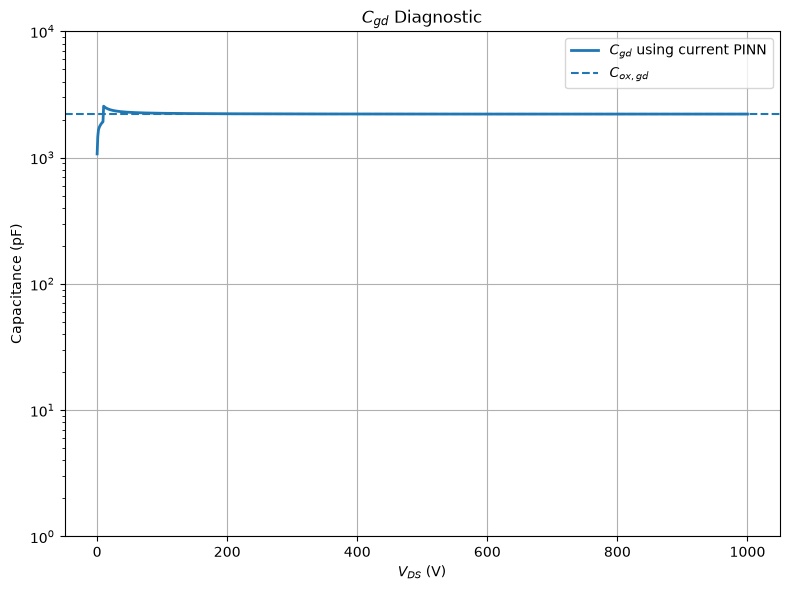

Maximum |Vgd| used in C-V = 500.0 V
Maximum Vds used in C-V = 500.0 V

The current phis_PINN was not trained over this full high-voltage C-V domain.


In [15]:
plt.figure(
    figsize=(8, 6)
)


plt.plot(
    Vds_cv.cpu().numpy(),
    Cgd_PINN_pF.cpu().numpy(),
    linewidth=2,
    label=r"$C_{gd}$ using current PINN",
)


plt.axhline(
    Coxgd * 1e12,
    linestyle="--",
    label=r"$C_{ox,gd}$",
)


plt.xlabel(
    r"$V_{DS}$ (V)"
)

plt.ylabel(
    "Capacitance (pF)"
)

plt.title(
    r"$C_{gd}$ Diagnostic"
)

plt.yscale(
    "log"
)

plt.ylim(
    1,
    1e4
)

plt.grid(
    True
)

plt.legend()

plt.tight_layout()

plt.show()
# ============================================================
# PINN training-domain warning
# ============================================================

print(
    "Maximum |Vgd| used in C-V =",
    torch.max(
        torch.abs(Vgd_eff)
    ).item(),
    "V"
)

print(
    "Maximum Vds used in C-V =",
    Vds_eff.max().item(),
    "V"
)

print(
    "\nWARNING:"
)

print(
    "The current phis_PINN was not trained "
    "over this full high-voltage C-V domain."
)